# 📊 Pandas GroupBy & Aggregation Guide

คู่มือสรุปการจัดกลุ่มและรวบรวมข้อมูลด้วย pandas

**เนื้อหา:**
1. groupby() พื้นฐาน
2. Aggregation functions (agg / aggregate)
3. Named Aggregation
4. groupby หลาย columns
5. transform() – เติมค่ากลับ row เดิม
6. filter() – กรองกลุ่ม
7. apply() – ฟังก์ชันเองได้เลย
8. pivot_table() และ crosstab()
9. resample() – สำหรับ time series
10. เทคนิค + ตัวอย่างจริง

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# สร้าง DataFrame ตัวอย่าง
# ======================================================
np.random.seed(42)

df = pd.DataFrame({
    'department': ['Sales','Sales','Sales','IT','IT','IT','HR','HR','HR','HR'],
    'gender':     ['M','F','M','F','M','M','F','F','M','F'],
    'level':      ['Senior','Junior','Junior','Senior','Senior','Junior','Junior','Senior','Junior','Senior'],
    'salary':     [70000,50000,55000,90000,85000,65000,45000,60000,48000,58000],
    'bonus':      [7000, 3000, 4000,12000,10000, 5000, 2000, 5000, 2500, 4000],
    'years':      [5, 2, 3, 8, 7, 3, 1, 4, 2, 5],
    'score':      [88, 75, 80, 95, 92, 78, 70, 85, 72, 82],
})

print(df.to_string())

  department gender   level  salary  bonus  years  score
0      Sales      M  Senior   70000   7000      5     88
1      Sales      F  Junior   50000   3000      2     75
2      Sales      M  Junior   55000   4000      3     80
3         IT      F  Senior   90000  12000      8     95
4         IT      M  Senior   85000  10000      7     92
5         IT      M  Junior   65000   5000      3     78
6         HR      F  Junior   45000   2000      1     70
7         HR      F  Senior   60000   5000      4     85
8         HR      M  Junior   48000   2500      2     72
9         HR      F  Senior   58000   4000      5     82


---
## 1. groupby() พื้นฐาน

In [2]:
# ======================================================
# 1.1 groupby + built-in aggregation
# ======================================================

# groupby column เดียว
g = df.groupby('department')

print('=== mean() ===')
print(g['salary'].mean())

print('\n=== sum() ===')
print(g['salary'].sum())

print('\n=== count() – นับ non-NaN ===')
print(g['salary'].count())

print('\n=== size() – นับทุกแถว (รวม NaN) ===')
print(g.size())

# Built-in agg functions:
# .mean()   .sum()    .count()   .size()
# .min()    .max()    .std()     .var()
# .median() .first()  .last()    .nunique()
# .prod()   .sem()    .skew()    .kurt()

=== mean() ===
department
HR       52750.000000
IT       80000.000000
Sales    58333.333333
Name: salary, dtype: float64

=== sum() ===
department
HR       211000
IT       240000
Sales    175000
Name: salary, dtype: int64

=== count() – นับ non-NaN ===
department
HR       4
IT       3
Sales    3
Name: salary, dtype: int64

=== size() – นับทุกแถว (รวม NaN) ===
department
HR       4
IT       3
Sales    3
dtype: int64


In [3]:
# ======================================================
# 1.2 PARAMETERS ของ groupby()
# ======================================================

# by          → column(s) ที่ใช้จัดกลุ่ม
# as_index    → ให้ group key เป็น index หรือไม่ (default=True)
# sort        → เรียง group (default=True)
# dropna      → ไม่รวม NaN group (default=True)
# observed    → สำหรับ Categorical: แสดงเฉพาะค่าที่มีจริง (default=False)

# as_index=False → ได้ DataFrame ปกติ (ไม่ใช้ group เป็น index)
print('as_index=False:')
print(df.groupby('department', as_index=False)['salary'].mean())

print('\nsort=False (เร็วกว่าสำหรับข้อมูลใหญ่):')
print(df.groupby('department', sort=False)['salary'].mean())

as_index=False:
  department        salary
0         HR  52750.000000
1         IT  80000.000000
2      Sales  58333.333333

sort=False (เร็วกว่าสำหรับข้อมูลใหญ่):
department
Sales    58333.333333
IT       80000.000000
HR       52750.000000
Name: salary, dtype: float64


---
## 2. agg() / aggregate() – รวมหลาย functions พร้อมกัน

In [4]:
# ======================================================
# 2.1 agg ด้วย list of functions
# ======================================================

print('=== agg หลาย functions บน 1 column ===')
result = df.groupby('department')['salary'].agg(['mean', 'min', 'max', 'std', 'count'])
print(result)

print('\n=== agg หลาย functions บนหลาย columns ===')
result2 = df.groupby('department')[['salary', 'bonus', 'score']].agg(['mean', 'sum'])
print(result2)
# ได้ MultiIndex columns: (salary, mean), (salary, sum), ...

=== agg หลาย functions บน 1 column ===
                    mean    min    max           std  count
department                                                 
HR          52750.000000  45000  60000   7365.459931      4
IT          80000.000000  65000  90000  13228.756555      3
Sales       58333.333333  50000  70000  10408.329997      3

=== agg หลาย functions บนหลาย columns ===
                  salary                bonus             score     
                    mean     sum         mean    sum       mean  sum
department                                                          
HR          52750.000000  211000  3375.000000  13500  77.250000  309
IT          80000.000000  240000  9000.000000  27000  88.333333  265
Sales       58333.333333  175000  4666.666667  14000  81.000000  243


In [5]:
# ======================================================
# 2.2 agg ด้วย dict – แต่ละ column ใช้ function ต่างกัน
# ======================================================

result3 = df.groupby('department').agg({
    'salary': ['mean', 'max'],
    'bonus':  'sum',
    'years':  'median',
    'score':  ['mean', 'min', 'max'],
})
print(result3)

# Flatten MultiIndex columns
result3.columns = ['_'.join(col) for col in result3.columns]
print('\nหลัง flatten columns:')
print(result3)

                  salary         bonus  years      score        
                    mean    max    sum median       mean min max
department                                                      
HR          52750.000000  60000  13500    3.0  77.250000  70  85
IT          80000.000000  90000  27000    7.0  88.333333  78  95
Sales       58333.333333  70000  14000    3.0  81.000000  75  88

หลัง flatten columns:
             salary_mean  salary_max  bonus_sum  years_median  score_mean  \
department                                                                  
HR          52750.000000       60000      13500           3.0   77.250000   
IT          80000.000000       90000      27000           7.0   88.333333   
Sales       58333.333333       70000      14000           3.0   81.000000   

            score_min  score_max  
department                        
HR                 70         85  
IT                 78         95  
Sales              75         88  


In [6]:
# ======================================================
# 2.3 agg ด้วย custom function
# ======================================================

# ฟังก์ชัน custom
def salary_range(x):
    return x.max() - x.min()

def top_earner_pct(x):
    """สัดส่วนคนที่ได้เงินเกิน 70000"""
    return (x > 70000).sum() / len(x)

result4 = df.groupby('department')['salary'].agg([
    'mean',
    salary_range,          # ใช้ชื่อฟังก์ชัน
    top_earner_pct,
    ('p90', lambda x: x.quantile(0.9)),  # tuple: (ชื่อที่ต้องการ, lambda)
])
print(result4)

                    mean  <function salary_range at 0x117c06840>  \
department                                                         
HR          52750.000000                                   15000   
IT          80000.000000                                   25000   
Sales       58333.333333                                   20000   

            <function top_earner_pct at 0x117c06980>      p90  
department                                                     
HR                                          0.000000  59400.0  
IT                                          0.666667  89000.0  
Sales                                       0.000000  67000.0  


---
## 3. Named Aggregation (pandas ≥ 0.25) – กำหนดชื่อ column ผลลัพธ์

In [7]:
# ======================================================
# 3. Named Aggregation – ชื่อสวย ไม่ต้อง rename ทีหลัง
# ======================================================

result5 = df.groupby('department').agg(
    avg_salary    = ('salary', 'mean'),
    max_salary    = ('salary', 'max'),
    min_salary    = ('salary', 'min'),
    total_bonus   = ('bonus',  'sum'),
    headcount     = ('salary', 'count'),
    avg_score     = ('score',  'mean'),
    med_years     = ('years',  'median'),
    salary_range  = ('salary', lambda x: x.max() - x.min()),
)
print(result5)

# รูปแบบ: new_col_name = ('source_column', 'agg_function')
# ดีกว่า dict เพราะได้ชื่อ column ที่ชัดเจนทันที

              avg_salary  max_salary  min_salary  total_bonus  headcount  \
department                                                                 
HR          52750.000000       60000       45000        13500          4   
IT          80000.000000       90000       65000        27000          3   
Sales       58333.333333       70000       50000        14000          3   

            avg_score  med_years  salary_range  
department                                      
HR          77.250000        3.0         15000  
IT          88.333333        7.0         25000  
Sales       81.000000        3.0         20000  


---
## 4. groupby หลาย Columns

In [8]:
# ======================================================
# 4.1 groupby หลาย columns
# ======================================================

result6 = df.groupby(['department', 'gender']).agg(
    count      = ('salary', 'count'),
    avg_salary = ('salary', 'mean'),
    avg_score  = ('score',  'mean'),
).round(0)
print(result6)

# ผลได้ MultiIndex (department, gender)

                   count  avg_salary  avg_score
department gender                              
HR         F           3     54333.0       79.0
           M           1     48000.0       72.0
IT         F           1     90000.0       95.0
           M           2     75000.0       85.0
Sales      F           1     50000.0       75.0
           M           2     62500.0       84.0


In [9]:
# ======================================================
# 4.2 reset_index() – แปลง MultiIndex กลับเป็น columns
# ======================================================

result7 = df.groupby(['department', 'level'], as_index=False).agg(
    count      = ('salary', 'count'),
    avg_salary = ('salary', 'mean'),
).round(0)
print(result7)

# หรือใช้ .reset_index() หลัง agg
result8 = df.groupby(['department', 'gender'])['salary'].mean().reset_index()
result8.columns = ['department', 'gender', 'avg_salary']
print('\nreset_index():')
print(result8)

  department   level  count  avg_salary
0         HR  Junior      2     46500.0
1         HR  Senior      2     59000.0
2         IT  Junior      1     65000.0
3         IT  Senior      2     87500.0
4      Sales  Junior      2     52500.0
5      Sales  Senior      1     70000.0

reset_index():
  department gender    avg_salary
0         HR      F  54333.333333
1         HR      M  48000.000000
2         IT      F  90000.000000
3         IT      M  75000.000000
4      Sales      F  50000.000000
5      Sales      M  62500.000000


unstack() – wide format:
gender            F        M
department                  
HR          54333.0  48000.0
IT          90000.0  75000.0
Sales       50000.0  62500.0


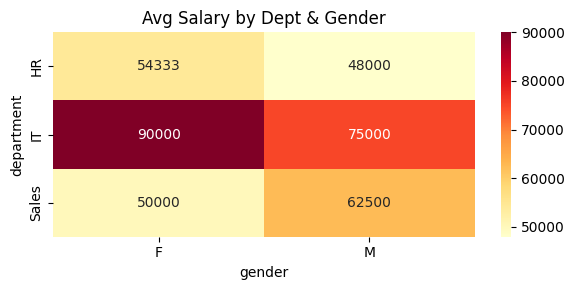

In [10]:
# ======================================================
# 4.3 unstack() – หมุน MultiIndex เป็น wide format
# ======================================================

salary_table = df.groupby(['department', 'gender'])['salary'].mean().unstack()
print('unstack() – wide format:')
print(salary_table.round(0))

# PARAMETERS unstack:
# level=-1       → unstack level สุดท้าย (default)
# level=0        → unstack level แรก
# fill_value=0   → เติมค่าที่ขาดหาย

# Heatmap จาก pivot
plt.figure(figsize=(6, 3))
sns.heatmap(salary_table, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Avg Salary by Dept & Gender')
plt.tight_layout()
plt.show()

---
## 5. transform() – คืนค่ากลับแถวเดิม (ขนาดเท่า df เดิม)

In [11]:
# ======================================================
# 5. transform()
# ======================================================
# ต่างจาก agg: transform ได้ Series ขนาดเท่า df เดิม
# → ใช้เพื่อเพิ่ม column สรุปกลับไปใน df

df2 = df.copy()

# เพิ่ม column avg salary ของ department นั้น
df2['dept_avg_salary'] = df2.groupby('department')['salary'].transform('mean')

# เพิ่ม column rank ภายใน department (เรียง salary)
df2['dept_salary_rank'] = df2.groupby('department')['salary'].rank(ascending=False)

# เพิ่ม column ว่าเงินเดือนสูงกว่า avg dept หรือไม่
df2['above_dept_avg'] = df2['salary'] > df2['dept_avg_salary']

# Z-score ภายใน department
df2['salary_zscore_dept'] = df2.groupby('department')['salary'].transform(
    lambda x: (x - x.mean()) / x.std()
).round(2)

print(df2[['department','gender','salary','dept_avg_salary',
           'dept_salary_rank','above_dept_avg','salary_zscore_dept']].to_string())

# transform PARAMETERS:
# func → 'mean','sum','min','max','std','rank' หรือ lambda
# → function ต้องคืน Series ขนาดเท่า group

  department gender  salary  dept_avg_salary  dept_salary_rank  above_dept_avg  salary_zscore_dept
0      Sales      M   70000     58333.333333               1.0            True                1.12
1      Sales      F   50000     58333.333333               3.0           False               -0.80
2      Sales      M   55000     58333.333333               2.0           False               -0.32
3         IT      F   90000     80000.000000               1.0            True                0.76
4         IT      M   85000     80000.000000               2.0            True                0.38
5         IT      M   65000     80000.000000               3.0           False               -1.13
6         HR      F   45000     52750.000000               4.0           False               -1.05
7         HR      F   60000     52750.000000               1.0            True                0.98
8         HR      M   48000     52750.000000               3.0           False               -0.64
9         

---
## 6. filter() – กรองทั้งกลุ่ม

In [12]:
# ======================================================
# 6. filter()
# ======================================================
# เลือกเฉพาะ groups ที่ผ่าน condition
# → ได้ rows ทั้งหมดของ group ที่ผ่าน (ไม่ใช่ผลสรุป)

# กรองเฉพาะ department ที่มีพนักงาน >= 3 คน
df_large = df.groupby('department').filter(lambda x: len(x) >= 3)
print('Departments with >= 3 people:')
print(df_large)

print()

# กรองเฉพาะ department ที่ avg salary > 60000
df_highpay = df.groupby('department').filter(
    lambda x: x['salary'].mean() > 60000
)
print('Departments with avg salary > 60000:')
print(df_highpay)

# filter(func) → func รับ group DataFrame, return True/False

Departments with >= 3 people:
  department gender   level  salary  bonus  years  score
0      Sales      M  Senior   70000   7000      5     88
1      Sales      F  Junior   50000   3000      2     75
2      Sales      M  Junior   55000   4000      3     80
3         IT      F  Senior   90000  12000      8     95
4         IT      M  Senior   85000  10000      7     92
5         IT      M  Junior   65000   5000      3     78
6         HR      F  Junior   45000   2000      1     70
7         HR      F  Senior   60000   5000      4     85
8         HR      M  Junior   48000   2500      2     72
9         HR      F  Senior   58000   4000      5     82

Departments with avg salary > 60000:
  department gender   level  salary  bonus  years  score
3         IT      F  Senior   90000  12000      8     95
4         IT      M  Senior   85000  10000      7     92
5         IT      M  Junior   65000   5000      3     78


---
## 7. apply() – ใช้ฟังก์ชัน custom ได้เต็มที่

In [13]:
# ======================================================
# 7.1 apply() – return scalar
# ======================================================

# apply คล้าย agg แต่ได้รับ group เป็น DataFrame ทั้ง group

def dept_summary(group_df):
    """สรุป department พร้อม custom logic"""
    return pd.Series({
        'count':        len(group_df),
        'avg_salary':   group_df['salary'].mean(),
        'total_payroll': group_df['salary'].sum() + group_df['bonus'].sum(),
        'top_earner':   group_df.loc[group_df['salary'].idxmax(), 'gender'],
        'pct_senior':   (group_df['level'] == 'Senior').mean() * 100,
    })

result_apply = df.groupby('department').apply(dept_summary)
print(result_apply)

            count    avg_salary  total_payroll top_earner  pct_senior
department                                                           
HR              4  52750.000000         224500          F   50.000000
IT              3  80000.000000         267000          F   66.666667
Sales           3  58333.333333         189000          M   33.333333


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64546/136987720.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_apply = df.groupby('department').apply(dept_summary)


In [14]:
# ======================================================
# 7.2 apply() – return DataFrame (top N per group)
# ======================================================

# Top 2 earners per department
top2_per_dept = df.groupby('department').apply(
    lambda g: g.nlargest(2, 'salary'),
    include_groups=False  # pandas >= 2.2
).reset_index(level=0)  # เอา dept index ออกมาเป็น column

print('Top 2 earners per department:')
print(top2_per_dept[['department','gender','level','salary']])

# apply() PARAMETERS:
# func              → function ที่รับ DataFrame (group)
# include_groups    → รวม group columns ใน function (pandas ≥ 2.2, default deprecated)
# group_keys=True   → เพิ่ม group keys เป็น index

Top 2 earners per department:
  department gender   level  salary
7         HR      F  Senior   60000
9         HR      F  Senior   58000
3         IT      F  Senior   90000
4         IT      M  Senior   85000
0      Sales      M  Senior   70000
2      Sales      M  Junior   55000


---
## 8. pivot_table() และ crosstab()

In [15]:
# ======================================================
# 8.1 pivot_table()
# ======================================================

pt = pd.pivot_table(
    df,
    values  = 'salary',          # column ที่จะสรุป
    index   = 'department',      # rows
    columns = 'level',           # columns
    aggfunc = 'mean',            # aggregation function
    fill_value = 0,              # เติมค่าที่ขาดหาย
    margins = True,              # เพิ่ม row/col รวม (Grand Total)
    margins_name = 'Total',
)
print('pivot_table (avg salary):')
print(pt.round(0))

# PARAMETERS pivot_table:
# values    → column ที่คำนวณ (หลายค่าได้ → list)
# index     → row grouping (หลายค่าได้ → list)
# columns   → column grouping
# aggfunc   → 'mean','sum','count','min','max' หรือ dict
# fill_value→ เติม NaN
# margins   → เพิ่ม subtotal
# observed  → สำหรับ Categorical

pivot_table (avg salary):
level        Junior   Senior    Total
department                           
HR          46500.0  59000.0  52750.0
IT          65000.0  87500.0  80000.0
Sales       52500.0  70000.0  58333.0
Total       52600.0  72600.0  62600.0


In [16]:
# ======================================================
# 8.2 pivot_table หลาย aggfunc
# ======================================================

pt2 = pd.pivot_table(
    df,
    values  = ['salary', 'score'],
    index   = 'department',
    columns = 'gender',
    aggfunc = {'salary': 'mean', 'score': ['mean', 'count']},
    fill_value = 0,
)
print(pt2.round(1))

             salary          score               
               mean          count     mean      
gender            F        M     F  M     F     M
department                                       
HR          54333.3  48000.0     3  1  79.0  72.0
IT          90000.0  75000.0     1  2  95.0  85.0
Sales       50000.0  62500.0     1  2  75.0  84.0


In [17]:
# ======================================================
# 8.3 crosstab() – นับความถี่ระหว่าง 2 categorical
# ======================================================

ct = pd.crosstab(
    df['department'],    # rows
    df['level'],         # columns
    margins=True,
    margins_name='Total'
)
print('crosstab (count):')
print(ct)

# แสดงเป็น % ตาม row
ct_pct = pd.crosstab(
    df['department'],
    df['level'],
    normalize='index'  # 'index'=row%, 'columns'=col%, 'all'=total%
) * 100
print('\ncrosstab (row %):')
print(ct_pct.round(1))

# PARAMETERS crosstab:
# index      → rows
# columns    → columns
# values     → ค่าที่จะ aggregate (ต้องระบุ aggfunc)
# aggfunc    → 'mean','sum', etc. (ถ้ามี values)
# normalize  → 'index','columns','all' หรือ False
# margins    → เพิ่ม totals
# dropna     → ไม่รวม NaN group

crosstab (count):
level       Junior  Senior  Total
department                       
HR               2       2      4
IT               1       2      3
Sales            2       1      3
Total            5       5     10

crosstab (row %):
level       Junior  Senior
department                
HR            50.0    50.0
IT            33.3    66.7
Sales         66.7    33.3


---
## 9. resample() – GroupBy สำหรับ Time Series

In [18]:
# ======================================================
# 9. resample() – จัดกลุ่มตามช่วงเวลา
# ======================================================

# สร้าง time series data
dates = pd.date_range('2024-01-01', periods=90, freq='D')
ts = pd.DataFrame({
    'date':  dates,
    'sales': np.random.randint(100, 500, 90),
    'cost':  np.random.randint(50, 200, 90),
})
ts = ts.set_index('date')

# Weekly resample
weekly = ts.resample('W').agg({
    'sales': 'sum',
    'cost':  'mean',
})
print('Weekly resample:')
print(weekly.head(6))

# Monthly resample
monthly = ts.resample('ME').agg(
    total_sales  = ('sales', 'sum'),
    avg_daily    = ('sales', 'mean'),
    max_sales    = ('sales', 'max'),
    avg_cost     = ('cost',  'mean'),
).round(1)
print('\nMonthly resample:')
print(monthly)

# Resample frequency codes:
# 'D'  → Daily
# 'W'  → Weekly (Sunday)
# 'ME' → Month End
# 'MS' → Month Start
# 'QE' → Quarter End
# 'YE' → Year End
# 'h'  → Hourly
# 'min'→ Minutely
# '2h' → ทุก 2 ชั่วโมง

Weekly resample:
            sales        cost
date                         
2024-01-07   1805  113.285714
2024-01-14   2025  119.857143
2024-01-21   2397  150.571429
2024-01-28   2339   95.571429
2024-02-04   1993  118.428571
2024-02-11   2043  127.000000

Monthly resample:
            total_sales  avg_daily  max_sales  avg_cost
date                                                   
2024-01-31         9697      312.8        485     117.7
2024-02-29         8810      303.8        487     121.8
2024-03-31         9322      310.7        489     127.8


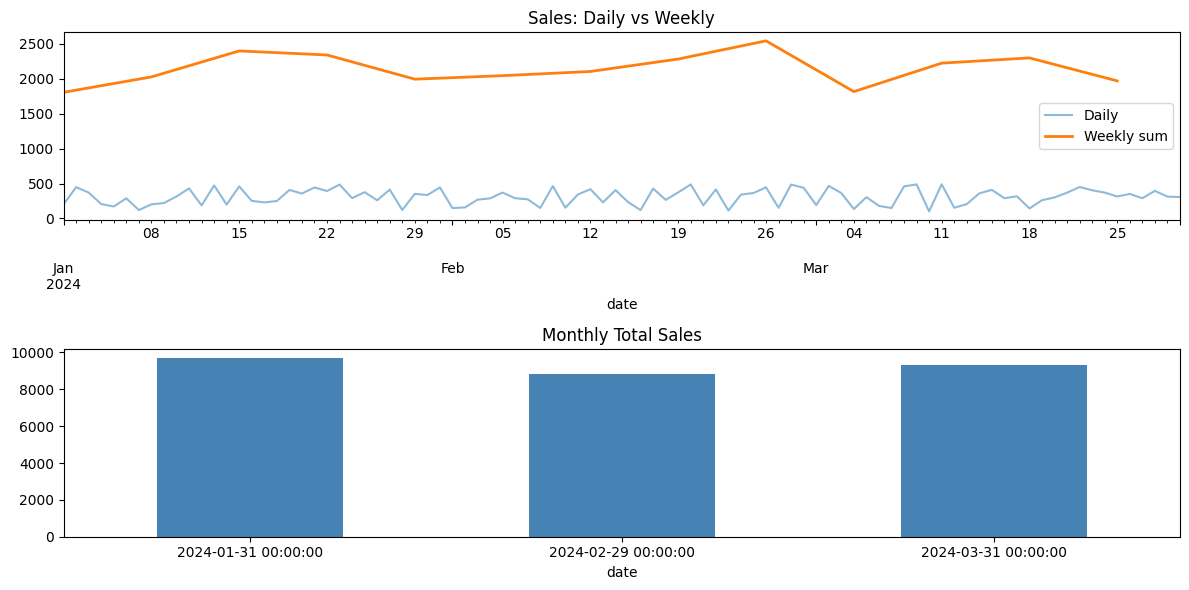

In [19]:
# plot time series
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

ts['sales'].plot(ax=axes[0], alpha=0.5, label='Daily')
ts['sales'].resample('W').sum().plot(ax=axes[0], label='Weekly sum', linewidth=2)
axes[0].set_title('Sales: Daily vs Weekly')
axes[0].legend()

monthly['total_sales'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Monthly Total Sales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 10. เทคนิคสำคัญ

In [20]:
# ======================================================
# 10.1 cumsum / cummax / cumprod ภายใน group
# ======================================================

df3 = df.sort_values(['department', 'salary']).copy()
df3['cumulative_salary'] = df3.groupby('department')['salary'].cumsum()
df3['running_max']       = df3.groupby('department')['salary'].cummax()
print(df3[['department','salary','cumulative_salary','running_max']].to_string())

  department  salary  cumulative_salary  running_max
6         HR   45000              45000        45000
8         HR   48000              93000        48000
9         HR   58000             151000        58000
7         HR   60000             211000        60000
5         IT   65000              65000        65000
4         IT   85000             150000        85000
3         IT   90000             240000        90000
1      Sales   50000              50000        50000
2      Sales   55000             105000        55000
0      Sales   70000             175000        70000


In [21]:
# ======================================================
# 10.2 shift() ภายใน group – lag/lead values
# ======================================================

# สร้าง time series per group
monthly_sales = pd.DataFrame({
    'month':  pd.date_range('2024-01', periods=6, freq='ME').tolist() * 2,
    'region': ['North']*6 + ['South']*6,
    'sales':  [100,120,90,130,150,110,80,95,105,88,112,98],
})

monthly_sales = monthly_sales.sort_values(['region','month'])

# Lag 1 month (เดือนก่อนหน้า)
monthly_sales['prev_month_sales'] = monthly_sales.groupby('region')['sales'].shift(1)

# Month-over-month growth
monthly_sales['mom_growth_%'] = (
    (monthly_sales['sales'] - monthly_sales['prev_month_sales'])
    / monthly_sales['prev_month_sales'] * 100
).round(1)

print(monthly_sales.to_string())

# shift(1)  → ค่า 1 แถวก่อนหน้า (lag)
# shift(-1) → ค่า 1 แถวถัดไป (lead)
# shift(n)  → lag n แถว

        month region  sales  prev_month_sales  mom_growth_%
0  2024-01-31  North    100               NaN           NaN
1  2024-02-29  North    120             100.0          20.0
2  2024-03-31  North     90             120.0         -25.0
3  2024-04-30  North    130              90.0          44.4
4  2024-05-31  North    150             130.0          15.4
5  2024-06-30  North    110             150.0         -26.7
6  2024-01-31  South     80               NaN           NaN
7  2024-02-29  South     95              80.0          18.8
8  2024-03-31  South    105              95.0          10.5
9  2024-04-30  South     88             105.0         -16.2
10 2024-05-31  South    112              88.0          27.3
11 2024-06-30  South     98             112.0         -12.5


In [22]:
# ======================================================
# 10.3 ngroup() – ให้เลขกลุ่ม, nth() – เลือกแถวที่ n
# ======================================================

df4 = df.copy()
df4['dept_id'] = df4.groupby('department').ngroup()
print('ngroup() – เลขกลุ่ม:')
print(df4[['department','dept_id']].drop_duplicates())

print('\nnth(0) – แถวแรกของแต่ละ group:')
print(df.groupby('department').nth(0)[['gender','salary']])

print('\nnth(-1) – แถวสุดท้ายของแต่ละ group:')
print(df.groupby('department').nth(-1)[['gender','salary']])

ngroup() – เลขกลุ่ม:
  department  dept_id
0      Sales        2
3         IT        1
6         HR        0

nth(0) – แถวแรกของแต่ละ group:
  gender  salary
0      M   70000
3      F   90000
6      F   45000

nth(-1) – แถวสุดท้ายของแต่ละ group:
  gender  salary
2      M   55000
5      M   65000
9      F   58000


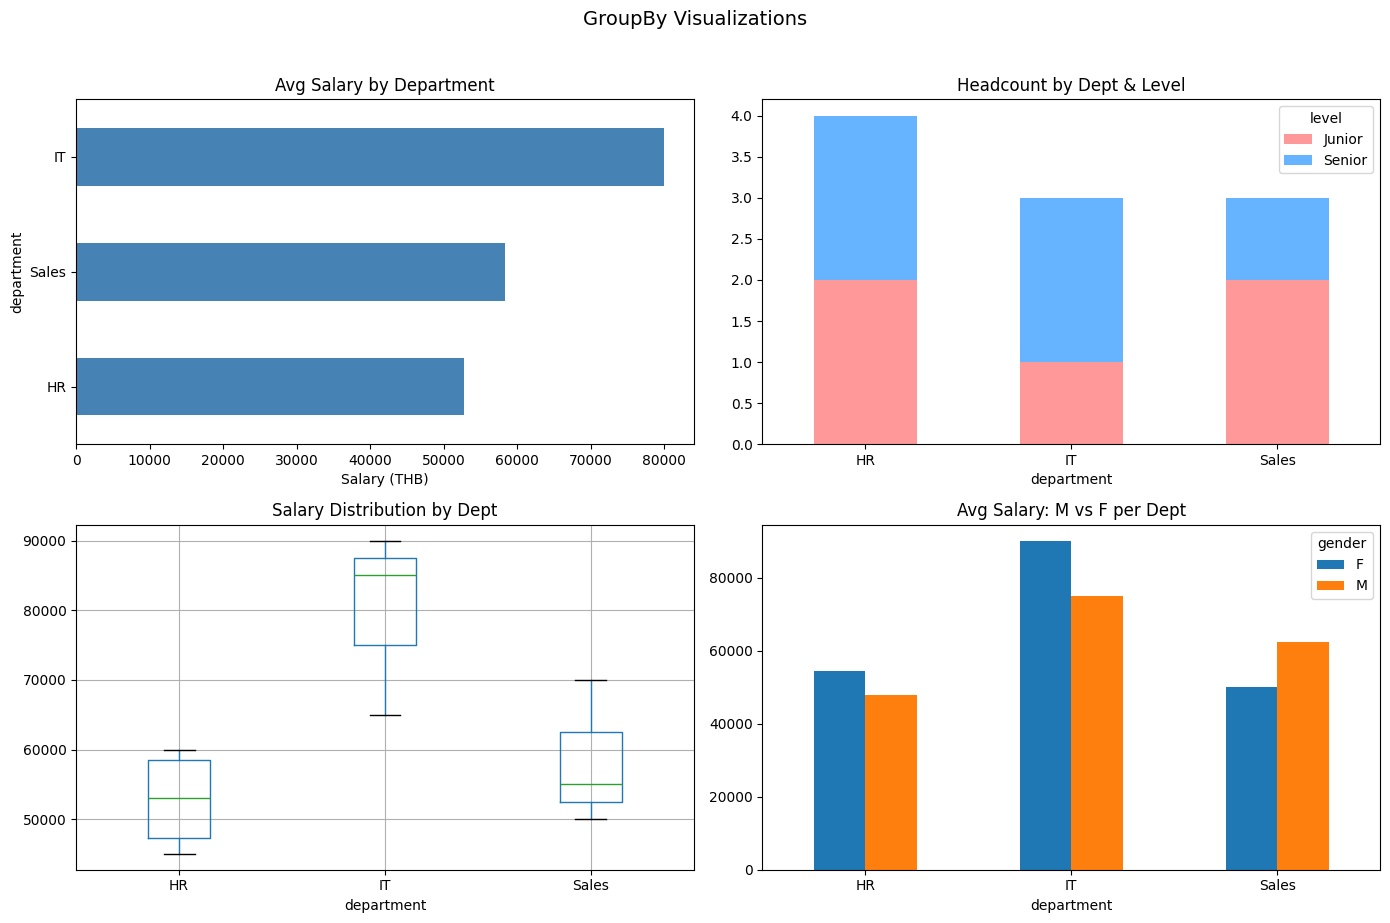

In [23]:
# ======================================================
# 10.4 Visualizing GroupBy Results
# ======================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Bar chart – avg salary per dept
df.groupby('department')['salary'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue'
)
axes[0,0].set_title('Avg Salary by Department')
axes[0,0].set_xlabel('Salary (THB)')

# Stacked bar – headcount by dept and level
pd.crosstab(df['department'], df['level']).plot(
    kind='bar', stacked=True, ax=axes[0,1],
    color=['#ff9999','#66b3ff']
)
axes[0,1].set_title('Headcount by Dept & Level')
axes[0,1].tick_params(axis='x', rotation=0)

# Box plot – salary distribution per dept
df.boxplot(column='salary', by='department', ax=axes[1,0])
axes[1,0].set_title('Salary Distribution by Dept')
plt.sca(axes[1,0])
plt.title('Salary Distribution by Dept')

# Line chart – gender salary comparison
df.groupby(['department','gender'])['salary'].mean().unstack().plot(
    kind='bar', ax=axes[1,1]
)
axes[1,1].set_title('Avg Salary: M vs F per Dept')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('GroupBy Visualizations', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
## สรุปตาราง

### groupby methods

| Method | Output size | ใช้เมื่อ |
|--------|-------------|----------|
| `.agg()` / `.aggregate()` | 1 row per group | สรุปผล เช่น mean, sum |
| `.transform()` | เท่า df เดิม | เพิ่ม column สรุปกลับใน df |
| `.filter()` | subset ของ df | คัดกลุ่มที่ผ่าน condition |
| `.apply()` | ยืดหยุ่น | custom logic ซับซ้อน |
| `.nth(n)` | 1 row per group | เลือกแถวที่ n ของแต่ละกลุ่ม |
| `.cumsum()` / `.cummax()` | เท่า df เดิม | running total ภายใน group |
| `.shift()` | เท่า df เดิม | lag/lead ภายใน group |

### agg functions

| Function | ความหมาย |
|----------|----------|
| `'mean'` | ค่าเฉลี่ย |
| `'median'` | มัธยฐาน |
| `'sum'` | ผลรวม |
| `'count'` | นับ non-NaN |
| `'size'` | นับทุก row รวม NaN |
| `'nunique'` | จำนวนค่า unique |
| `'min'` / `'max'` | ต่ำสุด / สูงสุด |
| `'std'` / `'var'` | ส่วนเบี่ยงเบน / variance |
| `'first'` / `'last'` | แถวแรก / สุดท้าย |
| `lambda x: ...` | custom function |

### groupby vs pivot_table vs crosstab

| | groupby | pivot_table | crosstab |
|--|---------|-------------|----------|
| Output | long format | wide format | wide format |
| ใช้กับ | ทั่วไป | สร้าง pivot |
| counts/freq |
| normalize | ไม่มีในตัว | ไม่มีในตัว | มีในตัว |
| margins (total) | ไม่มีในตัว | มีในตัว | มีในตัว |